Number of nodes: 4039
Number of edges: 88234
Average degree: 43.69
Average clustering coefficient: 0.6055
Diameter (largest connected component): 8
Density: 0.0108
Number of communities detected: 44
Community sizes: [198, 36, 10, 8, 8, 34, 2, 215, 16, 3, 3, 1030, 6, 7, 3, 3, 753, 10, 2, 2, 469, 13, 9, 3, 49, 25, 2, 60, 547, 179, 10, 9, 8, 226, 19, 4, 3, 8, 6, 14, 12, 7, 6, 2]


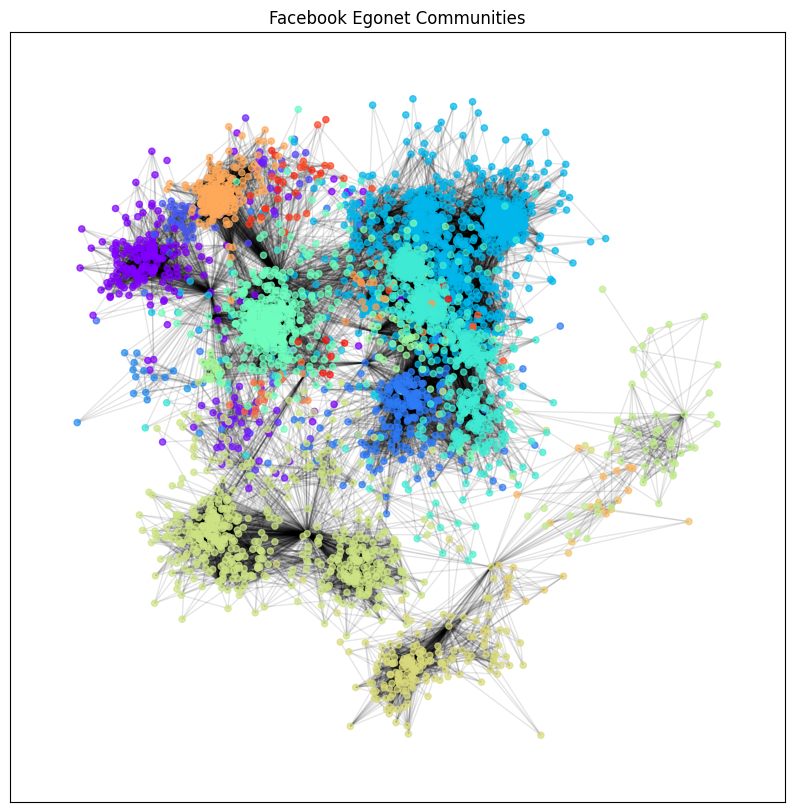


Top 5 nodes by Degree Centrality:
Node 107: 0.2588
Node 1684: 0.1961
Node 1912: 0.1870
Node 3437: 0.1355
Node 0: 0.0859

Top 5 nodes by Betweenness Centrality:
Node 107: 0.4805
Node 1684: 0.3378
Node 3437: 0.2361
Node 1912: 0.2293
Node 1085: 0.1490


In [ ]:
# Install and import required libraries
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import gzip

# Download and unzip the Facebook Egonet dataset
url = 'https://snap.stanford.edu/data/facebook_combined.txt.gz'
file_name = 'facebook_combined.txt.gz'
urllib.request.urlretrieve(url, file_name)

with gzip.open(file_name, 'rt') as f_in, open('facebook_combined.txt', 'w') as f_out:
    f_out.write(f_in.read())

# Load graph from edge list
G = nx.read_edgelist('facebook_combined.txt')
G.remove_edges_from(nx.selfloop_edges(G))

# Network characteristics
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Average degree: {avg_degree:.2f}")
print(f"Average clustering coefficient: {nx.average_clustering(G):.4f}")

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc)
print(f"Diameter (largest connected component): {nx.diameter(G_lcc)}")
print(f"Density: {nx.density(G):.4f}")

# Community Detection using Label Propagation
communities = list(nx.community.label_propagation_communities(G))
print(f"Number of communities detected: {len(communities)}")
community_sizes = [len(c) for c in communities]
print(f"Community sizes: {community_sizes}")

# Visualization of communities
node_color_map = {}
for i, community in enumerate(communities):
    for node in community:
        node_color_map[node] = i
colors = [node_color_map[node] for node in G.nodes()]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=20, cmap=plt.cm.rainbow, node_color=colors, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.title("Facebook Egonet Communities")
plt.show()

# Centrality Analysis
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

top_5_degree = sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:5]
top_5_betweenness = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)[:5]

print("\nTop 5 nodes by Degree Centrality:")
for node, cent in top_5_degree:
    print(f"Node {node}: {cent:.4f}")

print("\nTop 5 nodes by Betweenness Centrality:")
for node, cent in top_5_betweenness:
    print(f"Node {node}: {cent:.4f}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')